L'idée est de tester si la simple représentation sous forme de graphe avec une fonction de coût adaptée fournit les mêmes résultats pour le transport, que ceux obtenus en utilisant les *embeddings*. Cela permet de valider ou pas la pertinence d'une telle approche.

## Imports

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from collections import defaultdict
from poincare import PoincareManifold
from model import Distance_PE
from data_utils import *
from OT_utils import *
from information_content import *
from data import *
from evaluation import *

/home/onyxia/work/OT_simulation_maladies/Embeddings/OT_utils.py:428: SyntaxWarning: invalid escape sequence '\e'
  ax[0].set_ylabel('$||P^* - P_\epsilon^*||_F$', fontsize=25)
/home/onyxia/work/OT_simulation_maladies/Embeddings/OT_utils.py:432: SyntaxWarning: invalid escape sequence '\e'
  ax[1].set_xlabel('Regularization Strength $\epsilon$', fontsize=25)


Correspondances trouvées : 550


/home/onyxia/work/OT_simulation_maladies/Embeddings/data.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()


In [2]:
# Les 7 sous ontologies
inheritance = nx.ancestors(G_hpo_work, 'HP:0000005')
print(len(list(inheritance)))
onset = nx.ancestors(G_hpo_work, 'HP:0012823')
print(len(list(onset)))
abnormality = nx.ancestors(G_hpo_work, 'HP:0000118')
print(len(list(abnormality)))
history = nx.ancestors(G_hpo_work, 'HP:0032443')
print(len(list(history)))
biospecimen = nx.ancestors(G_hpo_work, 'HP:0020228')
print(len(list(biospecimen)))
blood = nx.ancestors(G_hpo_work, 'HP:0032223')
print(len(list(blood)))
frequency = nx.ancestors(G_hpo_work, 'HP:0040279')
print(len(list(frequency)))
print(len(G_hpo_work.nodes))
categories = {
    'inheritance': list(inheritance), 
    'onset' : list(onset), 
    'abnormality' : list(abnormality), 
    'history' : list(history), 
    'biospecimen' : list(biospecimen),
    'blood' : list(blood), 
    'frequency' : list(frequency)}

40
357
18690
198
85
8
6
19391


In [3]:
def term_categorie(df, node2id, categories):
    hpo_cols = [c for c in df.columns if c.startswith('HP')]
    id2idx = {node2id[hpo_cols[i]]: i for i in range(len(hpo_cols))}
    resultats = {cat: 0 for cat in categories.keys()}
    ids = defaultdict(list)
    for name, cat in categories.items():
        ids[name] = [
            id2idx[node2id[u]]
            for u in cat
            if u in node2id and node2id[u] in id2idx
        ]
    X = df[hpo_cols].values
    n = df.shape[0]
    for i in range(n):
        for cat in categories.keys():
            resultats[cat] += int(np.sum(X[i, ids[cat]]) > 0)
    taux = {cat: round(100 * count / n, 1) for cat, count in resultats.items()}
    return taux

taux_omim = term_categorie(work_omim.reset_index(drop=True), node2id_w, categories)
taux_orpha = term_categorie(work_orpha.reset_index(drop=True), node2id_w, categories)

## Utilisation de la table de correspondances d'Orphadata

In [3]:
# Bases de d'annotations binaires
work_omim = work_omim.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
work_orpha = work_orpha.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
hpo_cols0 = [c for c in work_omim.columns if c.startswith("HP:")]
df_orpha_omim_exact = df_orpha_omim[df_orpha_omim["mapping_type"]=='E (Exact mapping: the two concepts are equivalent)']
gt_set, valid_omim, valid_orpha = f_ground_truth(work_omim, work_orpha, df_orpha_omim_exact)
print(f"Taille OMIM : {work_omim.shape[0]}, ORPHA : {work_orpha.shape[0]}, paires GT : {len(gt_set)}")

Taille OMIM : 6686, ORPHA : 3189, paires GT : 2217


In [4]:
# Données avec les fréquences des termes HPO 
work_omimF = work_omimF.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
work_orphaF = work_orphaF.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)  # df_hpoa

work_omimF2 = work_omimF2.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
work_orphaF2 = work_orphaF2.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)  # Orphadata

hpo_colsF = [c for c in work_omimF.columns if c.startswith("HP:")]
hpo_colsF2 = [c for c in work_omimF2.columns if c.startswith("HP:")]

gt_setF, valid_omimF, valid_orphaF = f_ground_truth(work_omimF, work_orphaF, df_orpha_omim_exact)
gt_setF2, _, _ = f_ground_truth(work_omimF2, work_orphaF2, df_orpha_omim_exact)

print(f"Taille OMIM : {work_omimF.shape[0]}, ORPHA : {work_orphaF.shape[0]}, paires GT : {len(gt_setF)}")

Taille OMIM : 6686, ORPHA : 3189, paires GT : 2217


In [5]:
# Avec les maladies Orpha directement tirées d'Orphadata
work_omim2 = work_omim2.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
work_orpha2 = work_orpha2.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
hpo_cols2 = [c for c in work_omim2.columns if c.startswith("HP:")]

gt_set2, valid_omim2, valid_orpha2 = f_ground_truth(work_omim2, work_orpha2, df_orpha_omim_exact)
print(f"Taille OMIM : {work_omim2.shape}, ORPHA : {work_orpha2.shape}, paires GT : {len(gt_set2)}")

Taille OMIM : (6686, 11559), ORPHA : (3211, 11559), paires GT : 2237


In [ ]:
# Pour calculer les termes en commun
X_omim = work_omim[hpo_cols0].astype(int).values    # shape (n_omim, n_hpo)
X_orpha = work_orpha[hpo_cols0].astype(int).values  # shape (n_orpha, n_hpo)

n_omim = X_omim.sum(axis=1)    
m_orpha = X_orpha.sum(axis=1) 
common_matrix = X_omim @ X_orpha.T

gt_df = pd.DataFrame(list(gt_set), columns=['omim_pos', 'orpha_pos'])

omim_pos = gt_df['omim_pos'].values
orpha_pos = gt_df['orpha_pos'].values

gt_df['termes_communs'] = common_matrix[omim_pos, orpha_pos]
gt_df['n_omim'] = n_omim[omim_pos]
gt_df['m_orpha'] = m_orpha[orpha_pos]

denom = gt_df['n_omim'] + gt_df['m_orpha']
gt_df['dice_score'] = np.where(denom > 0, 2 * gt_df['termes_communs'] / denom, np.nan)

# Récupérer les vrais identifiants pour lecture/export
gt_df['omim_id'] = work_omim['database_id'].values[omim_pos]
gt_df['orpha_id'] = work_orpha['database_id'].values[orpha_pos]

df_scores = gt_df[['omim_id', 'orpha_id', 'n_omim', 'm_orpha', 'termes_communs', 'dice_score']]
print(df_scores.describe())
df_scores.head()

            n_omim      m_orpha  termes_communs   dice_score
count  2217.000000  2217.000000     2217.000000  2217.000000
mean     22.799278    27.464592        8.774470     0.328206
std      20.957944    20.191161        8.308504     0.169264
min       0.000000     2.000000        0.000000     0.000000
25%       8.000000    13.000000        3.000000     0.214286
50%      17.000000    22.000000        6.000000     0.322581
75%      31.000000    36.000000       12.000000     0.434783
max     193.000000   185.000000       59.000000     1.000000


,omim_id,orpha_id,n_omim,m_orpha,termes_communs,dice_score
0,OMIM:201180,ORPHA:1784,28,29,8,0.280702
1,OMIM:249600,ORPHA:2557,11,32,3,0.139535
2,OMIM:602484,ORPHA:2840,11,10,0,0.000000
3,OMIM:231680,ORPHA:26791,42,57,18,0.363636
4,OMIM:214800,ORPHA:138,89,94,37,0.404372


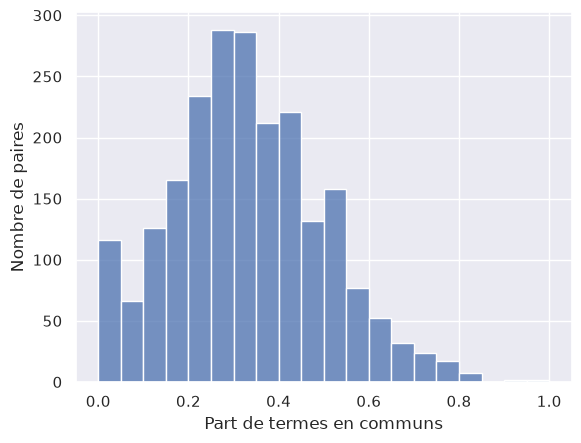

In [13]:
sns.set_theme()
sns.histplot(df_scores['dice_score'], bins=20)

plt.xlabel("Part de termes en communs")
plt.ylabel("Nombre de paires")
plt.show()

In [6]:
# Bases de données propagées
import tsw
ancestors = {hp: get_ancestors0(G_hpo_work, hp) for hp in hpo_cols0}
w_omim_P = tsw.propagate_terms(work_omim,  hpo_cols0, ancestors, depths, k=3)
w_orpha_P = tsw.propagate_terms(work_orpha, hpo_cols0, ancestors, depths, k=3)

w_omim_P2 = tsw.propagate_terms(work_omim2,  hpo_cols2, ancestors, depths, k=3)
w_orpha_P2 = tsw.propagate_terms(work_orpha2, hpo_cols2, ancestors, depths, k=3)

w_omim_PF2 = tsw.propagate_terms(work_omimF2, hpo_colsF2, ancestors, depths, k=3)
w_orpha_PF2 = tsw.propagate_terms(work_orphaF2, hpo_colsF2, ancestors, depths, k=3)

In [ ]:
# Pour calculer les termes en commun
X_omim = w_omim_P[hpo_cols0].astype(int).values    # shape (n_omim, n_hpo)
X_orpha = w_orpha_P[hpo_cols0].astype(int).values  # shape (n_orpha, n_hpo)

n_omim = X_omim.sum(axis=1)    
m_orpha = X_orpha.sum(axis=1) 
common_matrix = X_omim @ X_orpha.T

gt_df = pd.DataFrame(list(gt_set), columns=['omim_pos', 'orpha_pos'])

omim_pos = gt_df['omim_pos'].values
orpha_pos = gt_df['orpha_pos'].values

gt_df['termes_communs'] = common_matrix[omim_pos, orpha_pos]
gt_df['n_omim'] = n_omim[omim_pos]
gt_df['m_orpha'] = m_orpha[orpha_pos]

denom = gt_df['n_omim'] + gt_df['m_orpha']
gt_df['dice_score'] = np.where(denom > 0, 2 * gt_df['termes_communs'] / denom, np.nan)

# Récupérer les vrais identifiants pour lecture/export
gt_df['omim_id'] = w_omim_P['database_id'].values[omim_pos]
gt_df['orpha_id'] = w_orpha_P['database_id'].values[orpha_pos]

df_scores = gt_df[['omim_id', 'orpha_id', 'n_omim', 'm_orpha', 'termes_communs', 'dice_score']]
print(df_scores.describe())
df_scores.head()

            n_omim      m_orpha  termes_communs   dice_score
count  2217.000000  2217.000000     2217.000000  2217.000000
mean     81.497068    94.104195       47.691024     0.519354
std      68.522178    63.907872       38.969981     0.172389
min       0.000000     4.000000        0.000000     0.000000
25%      32.000000    47.000000       19.000000     0.417266
50%      62.000000    79.000000       37.000000     0.531469
75%     111.000000   124.000000       65.000000     0.631579
max     505.000000   520.000000      291.000000     1.000000


,omim_id,orpha_id,n_omim,m_orpha,termes_communs,dice_score
0,OMIM:201180,ORPHA:1784,139,142,77,0.548043
1,OMIM:249600,ORPHA:2557,64,124,43,0.457447
2,OMIM:602484,ORPHA:2840,50,44,15,0.319149
3,OMIM:231680,ORPHA:26791,141,168,88,0.569579
4,OMIM:214800,ORPHA:138,323,312,192,0.604724


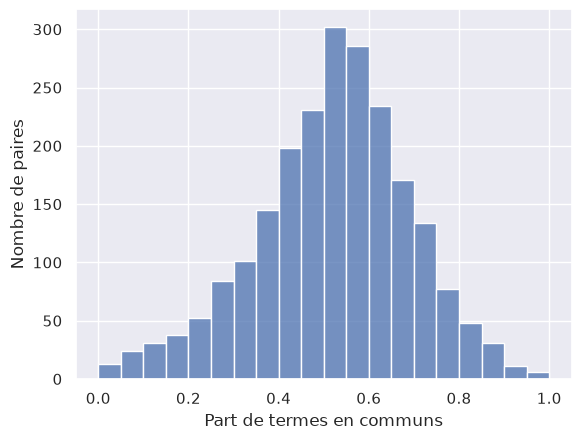

In [6]:
sns.set_theme()
sns.histplot(df_scores['dice_score'], bins=20)

plt.xlabel("Part de termes en communs")
plt.ylabel("Nombre de paires")
plt.show()

In [ ]:
# Ground truth incluant toutes les associations
gt_set_broad, _, _= f_ground_truth(work_omim, work_orpha, df_orpha_omim)
i_set = [a for a, b in gt_set]
d_gt = defaultdict(list)
for i, j in gt_set_broad:
    if np.isin(i, i_set):
        d_gt[i].append(j)

### Distances simples $l_2$, Jaccard, Hamming

In [ ]:
# Dictionnaire pour stocker les résultats méthode par méthode
dict_method={}

# Distances de base
for dist_method in ['jaccard', 'hamming']:
    print(dist_method)
    C = basic_cost_matrix(w_omim_P2, w_orpha_P2, dist_method)

    # Sans régularisation
    print("======== Sans régularisation ========")
    ot_plan, ot_cost = compute_transport(C, a=None, b=None)
    ranks, _, pairs, _ = evaluate_transport(ot_plan, gt_set2, C)

    # Avec régularisation
    print("======== Avec régularisation ========")
    grid = np.linspace(0.01, 5, 100)
    epsilon = grid[1] * np.mean(C)
    print(epsilon)
    ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
    ranks_reg, _, pairs_reg, _ = evaluate_transport(ot_plan_reg, gt_set2, C)
    print("")
    dict_method[f"{dist_method} reg"] = {"ranks": ranks_reg,
                                         "pairs": pairs_reg,
                                         "ot_plan": ot_plan_reg,
                                         "cost_matrix": C}

euclidean
Check : (6686, 3211)
======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.578 (1293/2237)
Top-3 accuracy : 0.607 (1357/2237)
Top-5 accuracy : 0.608 (1360/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.393 (879/2237)
Top-3 accuracy : 0.604 (1352/2237)
Top-5 accuracy : 0.608 (1359/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.393 (879/2237)
Top-3 accuracy : 0.603 (1350/2237)
Top-5 accuracy : 0.608 (1359/2237)
 Rang moyen des maladies Orpha : 635.46
 Rang moyen des maladies Omim : 981.90
======== Avec régularisation ========
0.6957322176062695
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.584 (1306/2237)
Top-3 accuracy : 0.705 (1578/2237)
Top-5 accuracy : 0.754 (1686/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.543 (1214/2237)
Top-3 accuracy : 0.651 (1457/2237)
Top-5 accuracy : 0.696 (1557/2237)
=========== Lignes et Colonnes ===========
Top-1 accura

In [10]:
# Distance euclidienne : bases de données avec les fréquences
C = basic_cost_matrix(work_omimF2, work_orphaF2, 'euclidean')

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C, a=None, b=None)
ranks, _, pairs, _ = evaluate_transport(ot_plan, gt_setF2, C)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _ = evaluate_transport(ot_plan_reg, gt_setF2, C)

Check : (6686, 3211)
======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.184 (412/2237)
Top-3 accuracy : 0.203 (453/2237)
Top-5 accuracy : 0.203 (455/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.110 (246/2237)
Top-3 accuracy : 0.202 (451/2237)
Top-5 accuracy : 0.202 (452/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.110 (246/2237)
Top-3 accuracy : 0.201 (450/2237)
Top-5 accuracy : 0.202 (452/2237)
 Rang moyen des maladies Orpha : 1287.27
 Rang moyen des maladies Omim : 2019.47
======== Avec régularisation ========
0.18266415090488683
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.175 (391/2237)
Top-3 accuracy : 0.242 (542/2237)
Top-5 accuracy : 0.277 (619/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.190 (424/2237)
Top-3 accuracy : 0.251 (562/2237)
Top-5 accuracy : 0.287 (643/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.135 (301/2237

Train : 1773
 Test : 444
Accuracy : 0.752
Precision: 0.801
Recall   : 0.752
ROC-AUC : 0.850
PR-AUC : 0.915


/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


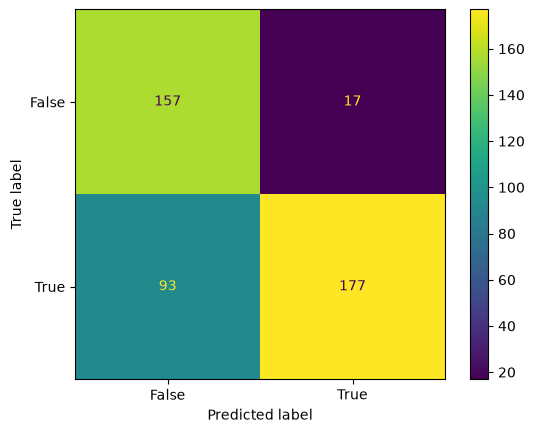

top_1       3.633973
sds        -3.576550
ratio_12    2.904296
dtype: float64
Seuil pour 90.0% précision : 0.462 (recall correspondant : 0.700)


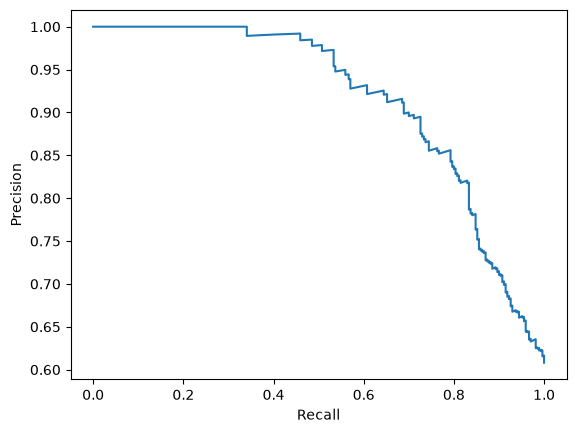

/home/onyxia/work/OT_simulation_maladies/Embeddings/evaluation.py:199: RuntimeWarning: invalid value encountered in divide
  C = (X @ Y.T)/np.sum(X, axis=1, keepdims=True)  # Part de termes en communs par rapport à OMIM


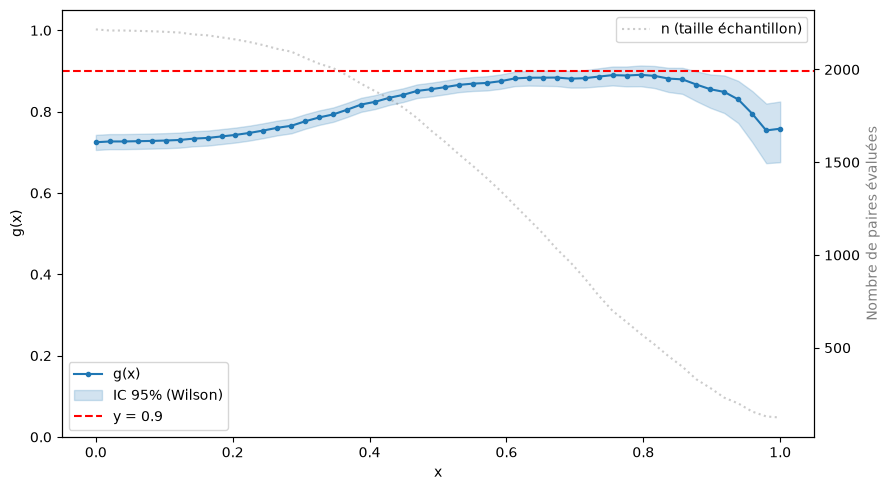

In [6]:
logistic_reg(dict_method['hamming reg']['ot_plan'], gt_set)
x, g = seuil_commun(w_omim_P, w_orpha_P, dict_method['hamming reg']['ot_plan'], gt_set, alpha=0.9)

### Distances pondérées en exploitant juste la structure d'arbre 

In [7]:
root = "HP:0000001"
depths = nx.single_source_shortest_path_length(G_hpo_work.reverse(), source=root)

C1 = cost_matrix_hamm(w_omim_P2, w_orpha_P2, depths)
print(np.isnan(C1).sum(), np.isinf(C).sum())

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C1, a=None, b=None)
ranks,_, pairs,_ = evaluate_transport(ot_plan, gt_set2, C1)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C1)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C1, None, None, epsilon, 10000, 1e-4, False)
ranks_reg,_, pairs_reg,_ = evaluate_transport(ot_plan_reg, gt_set2, C1)
dict_method["profondeur reg"]={"ranks": ranks_reg,
                        "pairs": pairs_reg,
                        "ot_plan": ot_plan_reg,
                        "cost_matrix": C1}

0 0
======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.589 (1317/2237)
Top-3 accuracy : 0.617 (1381/2237)
Top-5 accuracy : 0.619 (1384/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.397 (887/2237)
Top-3 accuracy : 0.618 (1382/2237)
Top-5 accuracy : 0.618 (1383/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.397 (887/2237)
Top-3 accuracy : 0.617 (1380/2237)
Top-5 accuracy : 0.618 (1383/2237)
 Rang moyen des maladies Orpha : 620.16
 Rang moyen des maladies Omim : 951.01
======== Avec régularisation ========
46.669587812690764
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.613 (1371/2237)
Top-3 accuracy : 0.737 (1649/2237)
Top-5 accuracy : 0.786 (1759/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.552 (1235/2237)
Top-3 accuracy : 0.664 (1486/2237)
Top-5 accuracy : 0.707 (1581/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.477 (1067/2237)
Top-

In [7]:
weights, diseases, all_diseases = compute_information_content(w_omim_P2, G_hpo_work)
weights = {t:-np.log(w) for t, w in weights.items()}

C1 = cost_matrix_hamm(w_omim_P2, w_orpha_P2, weights)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C1, a=None, b=None)
ranks, _, pairs, _ = evaluate_transport(ot_plan, gt_set2, C1)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C1)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C1, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _ = evaluate_transport(ot_plan_reg, gt_set2, C1)
# _, _ = evaluate_transport(ot_plan_reg, d_gt, C1, exact=False)
dict_method["ic"]={"ranks": ranks_reg,
                    "pairs": pairs_reg,
                    "ot_plan": ot_plan_reg,
                    "cost_matrix": C1}

======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.611 (1366/2237)
Top-3 accuracy : 0.639 (1429/2237)
Top-5 accuracy : 0.640 (1431/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.404 (903/2237)
Top-3 accuracy : 0.639 (1429/2237)
Top-5 accuracy : 0.639 (1429/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.404 (903/2237)
Top-3 accuracy : 0.638 (1428/2237)
Top-5 accuracy : 0.639 (1429/2237)
 Rang moyen des maladies Orpha : 591.58
 Rang moyen des maladies Omim : 891.42
======== Avec régularisation ========
72.05845892277502
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.631 (1411/2237)
Top-3 accuracy : 0.747 (1670/2237)
Top-5 accuracy : 0.792 (1772/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.574 (1284/2237)
Top-3 accuracy : 0.682 (1526/2237)
Top-5 accuracy : 0.727 (1627/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.499 (1116/2237)
Top-3 acc

NameError: name 'dict_method' is not defined

In [8]:
# Calcul de l'IC à partir des fréquences
weights, diseases, all_diseases = compute_information_content(w_omim_PF2, G_hpo_work)
weights = {t:-np.log(w) for t, w in weights.items()}

C1 = cost_matrix_hamm(w_omim_P2, w_orpha_P2, weights)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C1, a=None, b=None)
ranks, _, pairs, _ = evaluate_transport(ot_plan, gt_set2, C1)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C1)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C1, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _ = evaluate_transport(ot_plan_reg, gt_set2, C1)

======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.603 (1350/2237)
Top-3 accuracy : 0.638 (1428/2237)
Top-5 accuracy : 0.640 (1431/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.400 (895/2237)
Top-3 accuracy : 0.637 (1425/2237)
Top-5 accuracy : 0.639 (1429/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.400 (895/2237)
Top-3 accuracy : 0.636 (1423/2237)
Top-5 accuracy : 0.639 (1429/2237)
 Rang moyen des maladies Orpha : 590.89
 Rang moyen des maladies Omim : 892.72
======== Avec régularisation ========
71.63661286724658
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.627 (1402/2237)
Top-3 accuracy : 0.742 (1660/2237)
Top-5 accuracy : 0.788 (1762/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.568 (1271/2237)
Top-3 accuracy : 0.678 (1516/2237)
Top-5 accuracy : 0.723 (1618/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.496 (1110/2237)
Top-3 acc

Train : 1773
 Test : 444
Accuracy : 0.714
Precision: 0.757
Recall   : 0.714
ROC-AUC : 0.814
PR-AUC : 0.880


/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


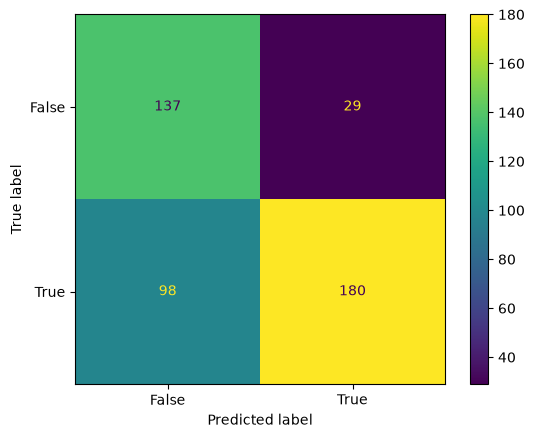

sds        -3.792349
top_1       3.755752
ratio_12    3.588361
dtype: float64
Seuil pour 90.0% précision : 0.653 (recall correspondant : 0.540)


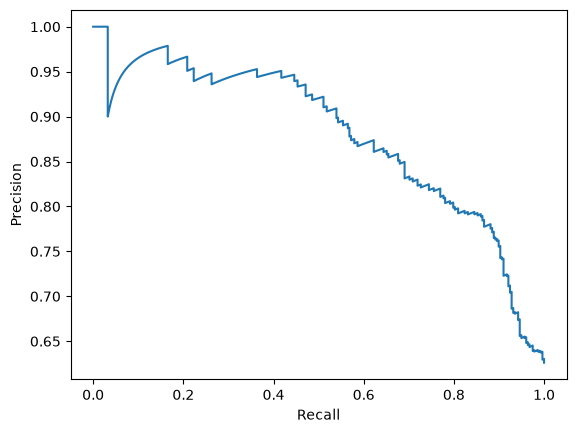

/home/onyxia/work/OT_simulation_maladies/Embeddings/evaluation.py:199: RuntimeWarning: invalid value encountered in divide
  C = (X @ Y.T)/np.sum(X, axis=1, keepdims=True)  # Part de termes en communs par rapport à OMIM


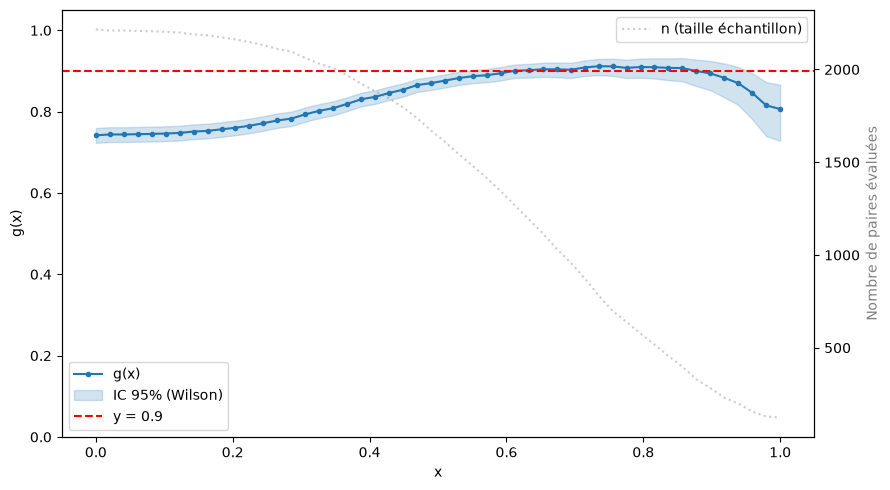

Pourcentage de termes partagés min : 61.0%
Pourcentage de termes partagés max : 86.0%


In [8]:
metrics, X_train, X_test, y_train, y_test, model = logistic_reg(dict_method['ic']['ot_plan'], gt_set)
x, y = seuil_commun(w_omim_P, w_orpha_P, dict_method['ic']['ot_plan'], gt_set, alpha=0.9)
print(f"Pourcentage de termes partagés min : {np.round(x[np.where(np.array(y)>0.9)[0][0]]*100)}%")
print(f"Pourcentage de termes partagés max : {np.round(x[np.where(np.array(y)>0.9)[0][-1]]*100)}%")

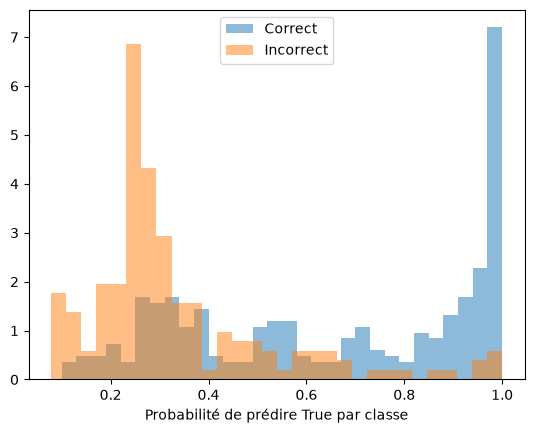

In [18]:
proba_test = model.predict_proba(X_test)[:, 1]
plt.hist(proba_test[y_test==np.True_], bins=30, alpha=0.5, label='Correct', density=True)
plt.hist(proba_test[y_test==np.False_], bins=30, alpha=0.5, label='Incorrect', density=True)
plt.xlabel("Probabilité de prédire True par classe")
plt.legend()

In [16]:
not_min=defaultdict(set)
for (i, j_true) in gt_set:
    j_pred = np.argmin(C1[i])
    if j_pred != j_true:
        not_min[(i,j_true)].add(j_pred)
        # print(f"C[i, j_true]={C1[i,j_true]:.3f}, C[i, j_pred]={C1[i,j_pred]:.3f}")
print(f"{len(not_min)}/{len(gt_set)} soit {np.round(len(not_min)/len(gt_set), 2)*100}%")

4800/5312 soit 90.0%


### Composition des distances de Jaccard et IC

In [ ]:
C_jacc = dict_method["jaccard reg"]["cost_matrix"]
C1_max = np.max(C1, axis=1, keepdims=True)
C1 = C1/C1_max
for a in [0.2, 0.4, 0.6, 0.8]:
    print("="*40)
    print(f"a = {a}")
    C_comp = a*C1 + (1-a)*C_jacc
    print("======== Sans régularisation ========")
    ot_plan, ot_cost = compute_transport(C_comp, a=None, b=None)
    ranks, pairs = evaluate_transport(ot_plan, gt_set, C_comp)

    # Avec régularisation
    print("======== Avec régularisation ========")
    grid = np.linspace(0.01, 5, 100)
    epsilon = grid[1] * np.mean(C_comp)
    print(epsilon)
    ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C_comp, None, None, epsilon, 10000, 1e-4, False)
    ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, gt_set, C_comp)
    

a = 0.2
======== Sans régularisation ========


Paires évaluées : 2217
Top-1 accuracy : 0.599 (1327/2217)
Top-3 accuracy : 0.625 (1386/2217)
Top-5 accuracy : 0.627 (1389/2217)
 Rang moyen: 604.22
======== Avec régularisation ========
0.04888787169153508
Paires évaluées : 2217
Top-1 accuracy : 0.585 (1298/2217)
Top-3 accuracy : 0.722 (1601/2217)
Top-5 accuracy : 0.774 (1715/2217)
 Rang moyen: 28.09
a = 0.4
======== Sans régularisation ========
Paires évaluées : 2217
Top-1 accuracy : 0.603 (1336/2217)
Top-3 accuracy : 0.629 (1394/2217)
Top-5 accuracy : 0.631 (1398/2217)
 Rang moyen: 597.35
======== Avec régularisation ========
0.04051826965654181
Paires évaluées : 2217
Top-1 accuracy : 0.590 (1308/2217)
Top-3 accuracy : 0.728 (1615/2217)
Top-5 accuracy : 0.777 (1723/2217)
 Rang moyen: 26.55
a = 0.6
======== Sans régularisation ========
Paires évaluées : 2217
Top-1 accuracy : 0.604 (1339/2217)
Top-3 accuracy : 0.630 (1396/2217)
Top-5 accuracy : 0.632 (1401/2217)
 Rang moyen: 595.85
======== Avec régularisation ========
0.03214866762154

### Distances qui exploitent l'*embedding*

In [7]:
checkpoint = torch.load('logs/2026_5_7/12/model_final.pt', map_location='cpu', weights_only=False)
hp = checkpoint['hyperparams']
objects = checkpoint['objects']
manifold = PoincareManifold()
model = Distance_PE(n=len(objects), dim=hp['dim'],
                       manifold=manifold, sparse=False, learn_curvature=False, init_curvature=1., weight_decay=0)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()


Distance_PE(
  (embeddings): Embedding(19389, 15)
)

In [10]:
C_mod = compute_cost_matrix_pseudo_jacc(w_omim_P2, w_orpha_P2, node2id_w, model)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C_mod, a=None, b=None)
ranks, _, pairs, _ = evaluate_transport(ot_plan, gt_set2, C_mod)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C_mod)
print(epsilon)
ot_plan_reg, ot_cost_reg = compute_transport_sinkhorn(C_mod, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _ = evaluate_transport(ot_plan_reg, gt_set2, C_mod)
dict_method["embedding_hamming"]={"ranks": ranks_reg,
                    "pairs": pairs_reg,
                    "ot_plan": ot_plan_reg,
                    "cost_matrix": C_mod}

Compute norms
Norms computed !
======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.598 (1338/2237)
Top-3 accuracy : 0.632 (1414/2237)
Top-5 accuracy : 0.634 (1418/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.409 (914/2237)
Top-3 accuracy : 0.631 (1411/2237)
Top-5 accuracy : 0.633 (1416/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.409 (914/2237)
Top-3 accuracy : 0.630 (1410/2237)
Top-5 accuracy : 0.633 (1416/2237)
 Rang moyen des maladies Orpha : 590.27
 Rang moyen des maladies Omim : 910.90
======== Avec régularisation ========
27.351243307641873
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.624 (1395/2237)
Top-3 accuracy : 0.749 (1676/2237)
Top-5 accuracy : 0.793 (1774/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.570 (1274/2237)
Top-3 accuracy : 0.675 (1511/2237)
Top-5 accuracy : 0.724 (1619/2237)
=========== Lignes et Colonnes ===========
Top-1 accura

In [8]:
C_wass = compute_costs_matrix_wasserstein2(work_omim2, work_orpha2, node2id_w, model, deprecated)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C_wass, a=None, b=None)
ranks, _, pairs, _ = evaluate_transport(ot_plan, gt_set2, C_wass)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C_wass)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C_wass, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _ = evaluate_transport(ot_plan_reg, gt_set2, C_wass)
#dict_method["embedding_wasserstein"]={"ranks": ranks_reg,
                    #"pairs": pairs_reg,
                    #"ot_plan": ot_plan_reg,
                    #"cost_matrix": C_wass}

Precompute...
Finished !
Precomputing full HPO distance matrix...


Distance matrix rows: 100%|██████████| 42/42 [00:02<00:00, 20.86it/s]


HPO distance matrix: (10646, 10646)


OMIM: 100%|██████████| 6686/6686 [34:13<00:00,  3.26it/s]


======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.565 (1263/2237)
Top-3 accuracy : 0.599 (1341/2237)
Top-5 accuracy : 0.600 (1343/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.375 (838/2237)
Top-3 accuracy : 0.598 (1338/2237)
Top-5 accuracy : 0.600 (1342/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.375 (838/2237)
Top-3 accuracy : 0.598 (1338/2237)
Top-5 accuracy : 0.599 (1341/2237)
 Rang moyen des maladies Orpha : 642.78
 Rang moyen des maladies Omim : 998.34
======== Avec régularisation ========
0.4215044497166467
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.559 (1251/2237)
Top-3 accuracy : 0.708 (1584/2237)
Top-5 accuracy : 0.768 (1717/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.537 (1202/2237)
Top-3 accuracy : 0.669 (1497/2237)
Top-5 accuracy : 0.713 (1594/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.471 (1054/2237)
Top-3 ac

In [8]:
C_wass = compute_costs_matrix_wasserstein2(work_omimF2, work_orphaF2, node2id_w, model, deprecated)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C_wass, a=None, b=None)
ranks, _, pairs, _ = evaluate_transport(ot_plan, gt_setF2, C_wass)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C_wass)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C_wass, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _ = evaluate_transport(ot_plan_reg, gt_setF2, C_wass)

Precompute...
Finished !
Precomputing full HPO distance matrix...


Distance matrix rows: 100%|██████████| 38/38 [00:01<00:00, 22.56it/s]


HPO distance matrix: (9477, 9477)


OMIM: 100%|██████████| 6686/6686 [26:21<00:00,  4.23it/s]


======== Sans régularisation ========
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.269 (602/2237)
Top-3 accuracy : 0.285 (637/2237)
Top-5 accuracy : 0.287 (641/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.175 (392/2237)
Top-3 accuracy : 0.285 (637/2237)
Top-5 accuracy : 0.285 (637/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.175 (392/2237)
Top-3 accuracy : 0.284 (636/2237)
Top-5 accuracy : 0.285 (637/2237)
 Rang moyen des maladies Orpha : 1134.13
 Rang moyen des maladies Omim : 1754.25
======== Avec régularisation ========
0.30765723992228405
Paires évaluées : 2237
=========== Lignes ===========
Top-1 accuracy : 0.278 (621/2237)
Top-3 accuracy : 0.356 (796/2237)
Top-5 accuracy : 0.395 (883/2237)
=========== Colonnes ===========
Top-1 accuracy : 0.273 (610/2237)
Top-3 accuracy : 0.349 (780/2237)
Top-5 accuracy : 0.378 (846/2237)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.232 (518/2237)
Top-3 accuracy : 0.

In [14]:
# Distance dans C entre la vraie paire vs le meilleur match trouvé
not_min=defaultdict(set)
for (i, j_true) in gt_set:
    j_pred = np.argmin(C_wass[i])
    if j_pred != j_true:
        not_min[(i,j_true)].add(j_pred)
        # print(f"C[i, j_true]={C_wass[i,j_true]:.3f}, C[i, j_pred]={C_wass[i,j_pred]:.3f}")
print(f"{len(not_min)}/{len(gt_set)} soit {np.round(len(not_min)/len(gt_set), 2)*100}%")

3663/5312 soit 69.0%


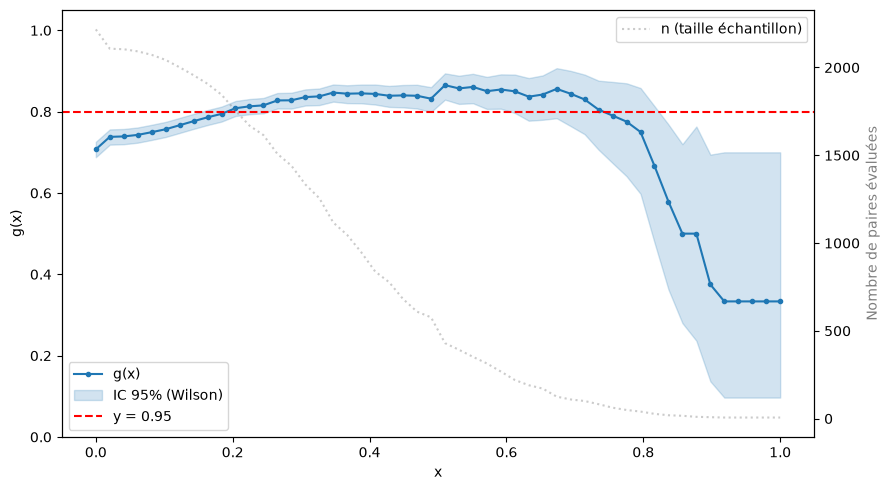

In [ ]:
# Evolution de Prob(bon match|nombre de termes partagés)
from scipy import stats

def wilson_ci(count, n, confidence=0.95):
    """Retourne (p_hat, borne_basse, borne_haute) via l'intervalle de Wilson."""
    if n == 0:
        return np.nan, np.nan, np.nan
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p_hat = count / n
    denom = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denom
    margin = (z * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))) / denom
    return p_hat, center - margin, center + margin

def communs(df1, df2):
    n=len(df1)
    m=len(df2)
    hpo_cols = [c for c in df1.columns if c.startswith('HP:')]
    X, Y = df1[hpo_cols].values, df2[hpo_cols].values
    C = (X @ Y.T)/np.sum(X, axis=1, keepdims=True)  # Part de termes en communs par rapport à OMIM
    return C

def g(x, C, P, gt_set, k=2):
    mask = C >= x
    #denom = mask.sum()/(n*m)  # Si l'on calcule la probabilité sur l'ensemble des maladies et pas seulement sur les paires
    count = 0
    denom = 0
    for i, j in gt_set:
        if not mask[i, j]:
            continue
        denom += 1
        ranked_cols = np.argsort(P[i])[::-1]
        rank = np.where(ranked_cols == j)[0]
        if len(rank) == 0:
            continue
        if mask[i, j] and rank[0]<=k :
            count+=1
    # count/=len(gt_set)
    if denom == 0:
        return np.nan
    return count, denom

C = communs(work_omim, work_orpha)
x_values = np.linspace(0, 1, 50)
results = [g(x, C, ot_plan_reg, gt_set) for x in x_values]
counts = [r[0] for r in results]
denoms = [r[1] for r in results]

ci_results = [wilson_ci(c, n) for c, n in zip(counts, denoms)]
g_values = [r[0] for r in ci_results]
lower_bounds = [r[1] for r in ci_results]
upper_bounds = [r[2] for r in ci_results]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(x_values, g_values, marker='o', markersize=3, color='tab:blue', label='g(x)')
ax1.fill_between(x_values, lower_bounds, upper_bounds, color='tab:blue', alpha=0.2, label='IC 95% (Wilson)')
ax1.axhline(y=0.8, color='red', linestyle='--', label='y = 0.95')
ax1.set_xlabel("x")
ax1.set_ylabel("g(x)")
ax1.set_ylim(0, 1.05)
ax1.legend(loc='lower left')

ax2 = ax1.twinx()
ax2.plot(x_values, denoms, color='tab:gray', alpha=0.4, linestyle=':', label='n (taille échantillon)')
ax2.set_ylabel("Nombre de paires évaluées", color='tab:gray')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Distance s'appuyant sur la similarité de Resnik

In [6]:
# Calcul de l'IC de chaque terme HPO
print("Compute information content...")
all_diseases = pd.concat([work_omim, work_orpha], ignore_index=True)
ic, _, _ = compute_information_content(all_diseases, G_hpo_work)
ic = {t:-np.log(w) for t, w in ic.items()}

# Calcul de la similarité entre chaque paire de termes HPO
print("Compute similarities...")
hpo_sim = resnik_similarity(all_diseases, G_hpo_work, ic)

Compute information content...
Compute similarities...
Precomputing ancestors...
Finished !


11524it [01:51, 103.78it/s]


In [7]:
def resnik_disease_similarities(df_omim, df_orpha, resnik_hpos, method):
    n = df_omim.shape[0]
    m = df_orpha.shape[0]

    colnames = [c for c in df_omim.columns if c.startswith('HP:')]
    X = df_omim[colnames].values
    Y = df_orpha[colnames].values
    n_active_x = X.sum(axis=1)
    n_active_y = Y.sum(axis=1)

    M = np.exp(-resnik_hpos)  # Matrice de similarités entre termes
    T = X.shape[1]
    d_max = M.max()
    
    if method == 'sum':
        C = X @ M @ Y.T

    if method == 'mean':
        S = X @ M @ Y.T
        n_active_x = X.sum(axis=1, keepdims=True)
        n_active_y = Y.sum(axis=1, keepdims=True)
        denom = n_active_x @ n_active_y.T
        denom[denom == 0] = 1
        return S / denom

    Q = np.full((n, T), d_max*2)
    for i in tqdm(range(n)):
        active_i = np.where(X[i] == 1)[0]  # termes actifs de la maladie i
        if len(active_i) == 0:
            continue
        Q[i, :] = M[active_i, :].min(axis=0)
    
    R = np.full((T, m), d_max*2)
    for j in tqdm(range(m)):
        active_j = np.where(Y[j] == 1)[0]  # termes actifs de la maladie j
        if len(active_j) == 0:
                continue
        R[:, j] = M[:, active_j].min(axis=1)

    row_sum = X @ np.where(np.isinf(R), d_max*2, R)
    row_best_mean = row_sum / np.maximum(n_active_x[:, None], 1)

    col_sum = np.where(np.isinf(Q), d_max*2, Q) @ Y.T
    col_best_mean = col_sum / np.maximum(n_active_y[None, :], 1)

    if method == 'funSimAvg':
        return (row_best_mean + col_best_mean) / 2

    if method == 'funSimMax':
        return np.minimum(row_best_mean, col_best_mean)  # distance : min = meilleur

    if method == 'bma':
        denom = n_active_x[:, None] + n_active_y[None, :]
        return (row_sum + col_sum) / denom

    if method == 'max':
        C = np.full((n, m), np.inf)
        for i in range(n):
            active_i = np.where(X[i] == 1)[0]
            if len(active_i) == 0:
                continue
            C[i, :] = R[active_i, :].min(axis=0)
        C = np.where(np.isinf(C), d_max*2, C)
        return C

    raise ValueError(f"Méthode inconnue : {method}")

In [24]:
#C_max = resnik_disease_similarities(work_omim, work_orpha, hpo_sim, 'max')
#C_mean = resnik_disease_similarities(work_omim, work_orpha, hpo_sim, 'mean')
#C_funSimAvg = resnik_disease_similarities(work_omim, work_orpha, hpo_sim, 'funSimAvg')
C_funSimMax = resnik_disease_similarities(work_omim, work_orpha, hpo_sim, 'funSimMax')
#C_bma = resnik_disease_similarities(work_omim, work_orpha, hpo_sim, 'bma')

100%|██████████| 3189/3189 [00:07<00:00, 441.49it/s]


In [14]:
C_bma.max()

np.float64(2.0)

In [25]:
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C_funSimMax, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, gt_set, C_funSimMax)

# Avec régularisation
print("======== Avec régularisation ========")
for eps in [5e-3, 0.01, 0.05, 0.1, 0.5]:
    epsilon = eps*np.mean(C_funSimMax)
    print(epsilon)
    ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C_funSimMax, None, None, epsilon, 100000, 1e-4, False)
    ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, gt_set, C_funSimMax)

======== Sans régularisation ========
Paires évaluées : 2217
Top-1 accuracy : 0.240 (531/2217)
Top-3 accuracy : 0.260 (576/2217)
Top-5 accuracy : 0.260 (576/2217)
 Rang moyen: 1214.45
 Rang médian: 1103.00
======== Avec régularisation ========
0.0001739761285199297
Paires évaluées : 2217
Top-1 accuracy : 0.238 (528/2217)
Top-3 accuracy : 0.325 (721/2217)
Top-5 accuracy : 0.364 (806/2217)
 Rang moyen: 215.16
 Rang médian: 25.00
0.0003479522570398594
Paires évaluées : 2217
Top-1 accuracy : 0.230 (511/2217)
Top-3 accuracy : 0.317 (703/2217)
Top-5 accuracy : 0.359 (796/2217)
 Rang moyen: 218.61
 Rang médian: 27.00
0.001739761285199297
Paires évaluées : 2217
Top-1 accuracy : 0.128 (284/2217)
Top-3 accuracy : 0.216 (479/2217)
Top-5 accuracy : 0.258 (571/2217)
 Rang moyen: 252.63
 Rang médian: 52.00
0.003479522570398594
Paires évaluées : 2217
Top-1 accuracy : 0.082 (181/2217)
Top-3 accuracy : 0.152 (337/2217)
Top-5 accuracy : 0.195 (432/2217)
 Rang moyen: 288.29
 Rang médian: 75.00
0.01739761

## Cas particulier : Hamming pondéré par l'IC, similarité sémantique

In [15]:
hpos = pd.read_csv("../data/HPOs.csv", sep=";")
id_to_name = dict(zip(hpos["hp_id"], hpos["name"]))

In [16]:
incorrect = [k for k, v in pairs_reg.items() if (v[0] > 3 or v[0]==0)]

paires_zero_dict = {}
hpo_cols = [c for c in work_omim.columns if c.startswith('HP:')]
omim_to_idx = {v: i for i, v in enumerate(work_omim['database_id'].values)} 
orpha_to_idx = {v: i for i, v in enumerate(work_orpha['database_id'].values)}
idx2omim={t:v for v,t in omim_to_idx.items()}
idx2orpha={t:v for v,t in orpha_to_idx.items()}

for (i,j) in incorrect:
    j_pred = np.argmax(ot_plan_reg[i])
    omim_row = work_omim.iloc[i][hpo_cols]
    orpha_row = work_orpha.iloc[j][hpo_cols]
    orpha_row_pred = work_orpha.iloc[j_pred][hpo_cols]

    omim_hpos  = omim_row[omim_row == 1].index.tolist()
    orpha_hpos = orpha_row[orpha_row == 1].index.tolist()
    orpha_hpos_pred = orpha_row_pred[orpha_row_pred == 1].index.tolist()

    disease_i = pd.unique(df_hpoa[df_hpoa['database_id']==idx2omim[i]]['disease_name'])[0]
    disease_j = pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[j]]['disease_name'])[0]
    disease_pred = pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[j_pred]]['disease_name'])[0]

    paires_zero_dict[(i, j)] = {
        "omim":  {"name": disease_i, "count": len(omim_hpos), "terms": omim_hpos},
        "orpha": {"name": disease_j, "count": len(orpha_hpos), "terms": orpha_hpos},
        "commun":{"true": set(omim_hpos)&set(orpha_hpos), "pred": set(omim_hpos)&set(orpha_hpos_pred)},
        "pred" : {"name": disease_pred, "count": len(orpha_hpos_pred), "terms":orpha_hpos_pred},
    }

In [17]:
ex = paires_zero_dict[(361,2612)]
t_omim = ex['omim']['terms']
t_orpha = ex['orpha']['terms']
t_pred = ex['pred']['terms']
name_omim = [id_to_name[t] for t in t_omim]
name_orpha = [id_to_name[t] for t in t_orpha]
name_pred = [id_to_name[t] for t in t_pred]
print("Omim :", name_omim)
print("Orpha : ", name_orpha)
print("Pred : ", name_pred )

Omim : ['Autosomal recessive inheritance', 'Hypertriglyceridemia', 'Increased LDL cholesterol concentration', 'Decreased HDL cholesterol concentration', 'Increased VLDL cholesterol concentration', 'Opacification of the corneal stroma']
Orpha :  ['Visual impairment', 'Angina pectoris', 'Splenomegaly', 'Hepatomegaly', 'Atherosclerosis', 'Lymphadenopathy', 'Decreased HDL cholesterol concentration', 'Corneal opacity']
Pred :  ['Renal insufficiency', 'Proteinuria', 'Visual impairment', 'Hemolytic anemia', 'Acute kidney injury', 'Hypertriglyceridemia', 'Atherosclerosis', 'Decreased HDL cholesterol concentration', 'Stage 5 chronic kidney disease', 'Premature coronary artery atherosclerosis', 'Corneal opacity', 'Decreased glomerular filtration rate', 'Decreased circulating apolipoprotein A-I concentration']


In [33]:
df_hpoa[df_hpoa["disease_name"]=='lcat deficiency']
print(df_orpha_omim[df_orpha_omim['orpha_id']=='ORPHA:650'])
print(df_hpoa[df_hpoa["disease_name"]=='fish eye disease'])

       orpha_id      omim_id  \
1603  ORPHA:650  OMIM:136120   
1604  ORPHA:650  OMIM:245900   

                                           mapping_type  
1603  BTNT (ORPHAcode is broader than the targeted c...  
1604  BTNT (ORPHAcode is broader than the targeted c...  
        database_id      disease_name qualifier      hpo_id    reference  \
147780  OMIM:136120  fish eye disease       NaN  HP:0007759  OMIM:136120   
147781  OMIM:136120  fish eye disease       NaN  HP:0002155  OMIM:136120   
147782  OMIM:136120  fish eye disease       NaN  HP:0003233  OMIM:136120   
147783  OMIM:136120  fish eye disease       NaN  HP:0003141  OMIM:136120   
147784  OMIM:136120  fish eye disease       NaN  HP:0003362  OMIM:136120   
147785  OMIM:136120  fish eye disease       NaN  HP:0000007  OMIM:136120   
281213  ORPHA:79292  fish eye disease       NaN  HP:0000505  ORPHA:79292   
281214  ORPHA:79292  fish eye disease       NaN  HP:0001681  ORPHA:79292   
281215  ORPHA:79292  fish eye disease       N

## Comparaison des résultats des différentes méthodes

In [5]:
import pickle

# Sauvegarde du dictionnaire
#with open("../data/utils/dict_method.pickle", 'wb') as file:
    #pickle.dump(dict_method, file)
with open("../data/utils/dict_method.pickle", 'rb') as file:
    dict_method = pickle.load(file)

inter = np.zeros((len(dict_method.keys()), len(dict_method.keys())))
inter_null = np.zeros((len(dict_method.keys()), len(dict_method.keys())))
# Initialisation
overall_correct = gt_set
overall_incorrect = gt_set
# Matrice des corrélations entre coûts
cost_corr = np.zeros((len(dict_method), len(dict_method)))
for i, method1 in enumerate(dict_method.keys()):
    C1 = dict_method[method1]["cost_matrix"].flatten()

    pairsi = dict_method[method1]["pairs"]
    correct_pairsi = [k for k, v in pairsi.items() if (v[0] <= 3 and v[0]!=0)]

    pairs0i = [k for k, v in pairsi.items() if (v[0] > 3 or v[0]==0)]
    
    overall_correct = overall_correct & set(correct_pairsi)
    overall_incorrect = overall_incorrect & set(pairs0i)
    for j, method2 in enumerate(dict_method.keys()):
        C2 = dict_method[method2]["cost_matrix"].flatten()
        cost_corr[i, j]=np.corrcoef(C1, C2)[0,1]

        pairsj = dict_method[method2]["pairs"]
        correct_pairsj = [k for k, v in pairsj.items() if (v[0] <= 3 and v[0]!=0)]
        pairs0j = [k for k, v in pairsj.items() if (v[0] > 3 or v[0]==0)]
        inter[i, j] = np.round(len(set(correct_pairsi)&set(correct_pairsj))/len(correct_pairsi)*100, 0)
        inter_null[i, j] = np.round(len((set(pairs0i)&set(pairs0j)))/len(pairs0i)*100, 0)

# Corrélation entre les matrices de coûts
print(dict_method.keys())
print(cost_corr)
print("")

# Paires communes correctement ou incorrectement transportées
print(dict_method.keys())
print("Paires correctement transportées en commun")
print(inter)
print("Paires incorrectement transportées en commun")
print(inter_null)
print("Check : ", overall_correct&overall_incorrect)

dict_keys(['euclidean reg', 'jaccard reg', 'hamming reg', 'profondeur reg', 'ic', 'embedding_hamming', 'embedding_wasserstein', 'hgcn'])
[[ 1.         -0.24726567  0.98514713  0.97296963  0.97645489  0.97820688
  -0.21720362 -0.13363148]
 [-0.24726567  1.         -0.24155996 -0.27029442 -0.25651036 -0.26713633
   0.68662355  0.66944958]
 [ 0.98514713 -0.24155996  1.          0.99253124  0.99582721  0.99685262
  -0.21566392 -0.13550269]
 [ 0.97296963 -0.27029442  0.99253124  1.          0.98935899  0.99222699
  -0.24686527 -0.15798727]
 [ 0.97645489 -0.25651036  0.99582721  0.98935899  1.          0.99786259
  -0.21538113 -0.14127477]
 [ 0.97820688 -0.26713633  0.99685262  0.99222699  0.99786259  1.
  -0.22230649 -0.15432791]
 [-0.21720362  0.68662355 -0.21566392 -0.24686527 -0.21538113 -0.22230649
   1.          0.49026297]
 [-0.13363148  0.66944958 -0.13550269 -0.15798727 -0.14127477 -0.15432791
   0.49026297  1.        ]]

dict_keys(['euclidean reg', 'jaccard reg', 'hamming reg', 'pr

In [8]:
len(overall_correct)

1094

Les matrices de coûts sont très corrélées entre elles (à l'exception d'une), ce qui peut expliquer les résultats similaires. De plus, les maladies correctement transportées sont en grande majorité les mêmes d'une méthode à l'autre (ce qui paraît logique une fois que l'on sait que les matrices de coût sont très fortement corrélées).

In [6]:
# Propagation des parents des termes actifs
ancestors = {hp: get_ancestors0(G_hpo_work, hp) for hp in hpo_cols0}

def propagate_pivot(df, ancestors):
    hp_cols = [c for c in df.columns if c.startswith('HP:')]
    df_prop = df.copy()
    for hp in hp_cols:
        descendants = [d for d in hp_cols if hp in ancestors.get(d, set())]
        if descendants:
            df_prop[hp] = df[[hp] + descendants].max(axis=1)
    return df_prop

#work_omim0_P = propagate_pivot(work_omim0, ancestors)
#work_orpha0_P = propagate_pivot(work_orpha0, ancestors)

In [13]:
# Maladies correctement/incorrectement transportées
paires_zero_dict = {}
paires_correct_dict = {}
hpo_cols = [c for c in work_omim.columns if c.startswith('HP:')]
omim_to_idx = {v: i for i, v in enumerate(work_omim['database_id'].values)} 
orpha_to_idx = {v: i for i, v in enumerate(work_orpha['database_id'].values)}
idx2omim={t:v for v,t in omim_to_idx.items()}
idx2orpha={t:v for v,t in orpha_to_idx.items()}

for (i,j) in  overall_incorrect:
    omim_row  = work_omim.iloc[i][hpo_cols]
    orpha_row = work_orpha.iloc[j][hpo_cols]
    omim_hpos  = omim_row[omim_row == 1].index.tolist()
    orpha_hpos = orpha_row[orpha_row == 1].index.tolist()
    disease_i = pd.unique(df_hpoa[df_hpoa['database_id']==idx2omim[i]]['disease_name'])[0]
    disease_j = pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[j]]['disease_name'])[0]

    paires_zero_dict[(i, j)] = {
        "omim":  {"name": disease_i, "count": len(omim_hpos), "terms": omim_hpos},
        "orpha": {"name": disease_j, "count": len(orpha_hpos), "terms": orpha_hpos},
        "commun":set(omim_hpos)&set(orpha_hpos),
    }
for (i, j) in overall_correct:
    omim_row  = work_omim.iloc[i][hpo_cols]
    orpha_row = work_orpha.iloc[j][hpo_cols]
    omim_hpos = omim_row[omim_row == 1].index.tolist()
    orpha_hpos = orpha_row[orpha_row == 1].index.tolist()
    disease_i = pd.unique(df_hpoa[df_hpoa['database_id']==idx2omim[i]]['disease_name'])[0]
    disease_j = pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[j]]['disease_name'])[0]

    paires_correct_dict[(i, j)] = {
        "omim":  {"name": disease_i, "count": len(omim_hpos), "terms": omim_hpos},
        "orpha": {"name": disease_j, "count": len(orpha_hpos), "terms": orpha_hpos},
        "commun":set(omim_hpos)&set(orpha_hpos),
    }

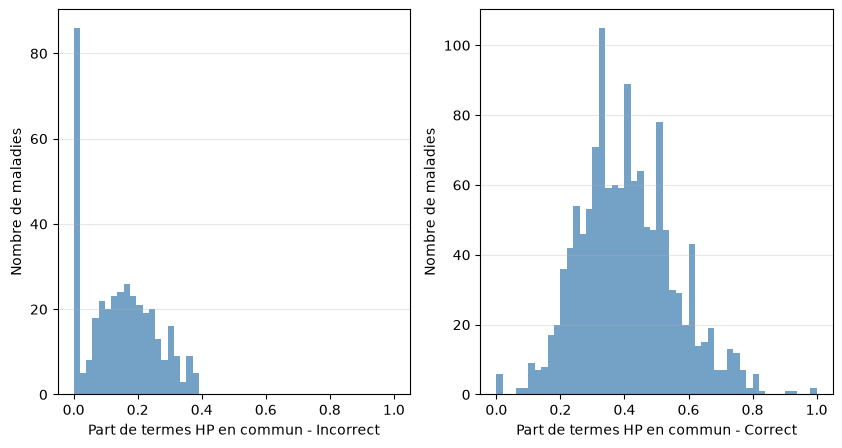

In [16]:
# Histplot part de termes en commun entre maladies omim et orpha
var1 = [2*len(paires_zero_dict[c]["commun"])/(paires_zero_dict[c]["omim"]["count"]+paires_zero_dict[c]["orpha"]["count"]) for c in paires_zero_dict.keys()]
var2 = [2*len(paires_correct_dict[c]["commun"])/(paires_correct_dict[c]["omim"]["count"]+paires_correct_dict[c]["orpha"]["count"]) for c in paires_correct_dict.keys()]
#var3 = [len(paires_correct_dict[c]["commun propagé"])/len(paires_correct_dict[c]["omim"]["terms propagated"]) for c in paires_correct_dict.keys()]
#var4 = [len(paires_zero_dict[c]["commun propagé"])/len(paires_zero_dict[c]["omim"]["terms propagated"]) for c in paires_zero_dict.keys()]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

ax = axes[0]
sns.histplot(var1, bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de termes HP en commun - Incorrect")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(var2, bins=50, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de termes HP en commun - Correct")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)
'''
ax = axes[1,0]
sns.histplot(var4, bins=50, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de termes HP en commun - Incorrect")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

ax = axes[1, 1]
sns.histplot(var3, bins=50, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de termes HP en commun - Correct")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
'''
plt.show()

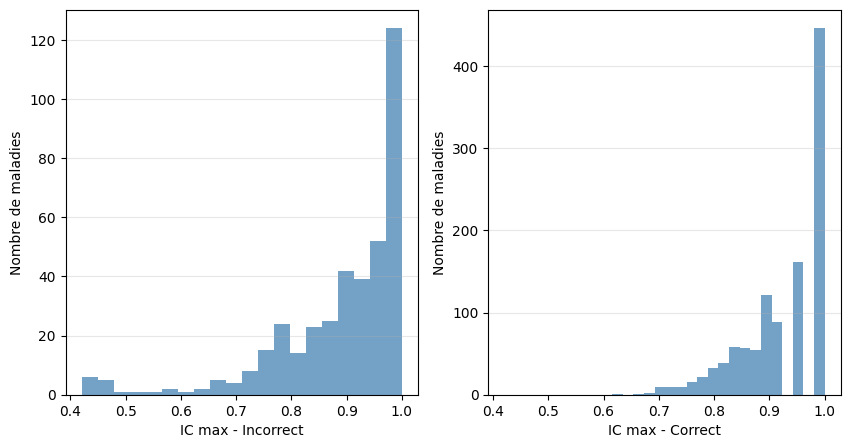

In [17]:
# Différences en terme d'information content
def max_ic(terms, ic):
    max_ic = ic[max(ic)]
    vals = [ic.get(t, 0)/max_ic for t in terms if t in ic]
    return np.max(vals) if vals else 0

ic_zero = [max_ic(paires_zero_dict[c]["omim"]["terms"], ic) for c in paires_zero_dict]
ic_correct = [max_ic(paires_correct_dict[c]["omim"]["terms"], ic) for c in paires_correct_dict]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

ax = axes[0]
sns.histplot(ic_zero, bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("IC max - Incorrect")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(ic_correct, bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("IC max - Correct")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)


In [7]:
from collections import Counter

terms_zero = Counter(t for c in paires_zero_dict.values() for t in c["omim"]["terms"])
terms_correct = Counter(t for c in paires_correct_dict.values() for t in c["omim"]["terms"])

n_zero = len(paires_zero_dict)
n_correct = len(paires_correct_dict)

overrepresented = {
    t: (terms_zero[t]/n_zero) - (terms_correct.get(t, 1e-9)/n_correct)
    for t in terms_zero
}
top_terms = sorted(overrepresented, key=overrepresented.get, reverse=True)[:10]
for t in top_terms:
    print(f"{t}: diff={overrepresented[t]:.2f}, freq_incorrect={terms_zero[t]/n_zero:.2f}, freq_correct={terms_correct.get(t,0)/n_correct:.2f}")

HP:0000006: diff=0.05, freq_incorrect=0.41, freq_correct=0.36
HP:0003236: diff=0.04, freq_incorrect=0.08, freq_correct=0.04
HP:0001442: diff=0.04, freq_incorrect=0.05, freq_correct=0.01
HP:0003677: diff=0.03, freq_incorrect=0.06, freq_correct=0.03
HP:0003581: diff=0.02, freq_incorrect=0.05, freq_correct=0.03
HP:0003693: diff=0.02, freq_incorrect=0.04, freq_correct=0.02
HP:0003560: diff=0.02, freq_incorrect=0.03, freq_correct=0.01
HP:0003701: diff=0.02, freq_incorrect=0.04, freq_correct=0.02
HP:0002505: diff=0.02, freq_incorrect=0.03, freq_correct=0.01
HP:0002460: diff=0.02, freq_incorrect=0.03, freq_correct=0.02


In [8]:
# Surreprésentation de certains noeuds ?
ancestors = {hp : get_ancestors0(G_hpo_work, hp) for hp in hpo_cols0}

def get_levelk_ancestors(terms, ancestors, depths, k=3):
    """
    Retourne tous les termes ancêtres de profondeur k.
    """
    chapters = set()
    for t in terms:
        for anc in ancestors[t]:
            if depths.get(anc, 99) == k:
                chapters.add(anc)
    return chapters

chapters_zero = Counter(a for c in paires_zero_dict.values()
                           for a in get_levelk_ancestors(c["omim"]["terms"], G_hpo_work, depths))
chapters_correct = Counter(a for c in paires_correct_dict.values()
                           for a in get_levelk_ancestors(c["omim"]["terms"], G_hpo_work, depths))

print("\nParents surreprésentés dans les maladies incorrectes:")
for chap, count in chapters_zero.most_common(10):
    ratio = (count/n_zero) / (chapters_correct.get(chap, 1e-9)/n_correct)
    print(f"{chap}: {count} ({ratio:.2f}x)")



Parents surreprésentés dans les maladies incorrectes:
HP:0003674: 86 (0.75x)
HP:0012638: 78 (0.64x)
HP:0001510: 57 (0.48x)
HP:0000002: 50 (0.53x)
HP:0012373: 24 (0.45x)
HP:0001417: 22 (0.66x)
HP:0002795: 17 (0.82x)
HP:0012531: 16 (0.76x)
HP:0001892: 13 (3.72x)
HP:0003679: 13 (0.57x)


In [20]:
# Qu'est ce qui sépare les maladies mal transportées ? Distance via LCA
def find_lca(u, v, ancestors, depths):
    """Trouve le plus proche ancêtre commun entre deux noeuds"""
    if u==v:
        return u, depths[u]
    parents_u = ancestors[u]
    parents_v = ancestors[v]
    parents = set(parents_u) & set(parents_v)
    if not parents:
        return None, 0  # -np.inf ?
    lca = max(parents, key=lambda n: depths[n])
    return lca, depths[lca]

def lca_diseases(d1, d2, ancestors, depths, omit=True):
    """
    Inputs : 
        - d1, d2 : maladies sous la forme d'une liste de leurs termes actifs.
        - ancestors : dictionnaire {'HP...':liste des parents}
        - depths : dictionnaire {'HP...':profondeur}
        - omit : True si l'on ne prend pas en compte les termes égaux.
    Outputs :
        - bests : liste des profondeurs des plus proches ancêtres communs pour chaque terme de d1 avec d2.
        - lcas : dictionnaire {'HP...':lca} pour chaque terme de d1.
    """
    bests = [-np.inf for k in range(len(d1))]
    lcas = defaultdict()
    for i in range(len(d1)):
        for j in range(len(d2)):
            if d1[i]==d2[j] and omit:
                continue
            lca, d = find_lca(d1[i], d2[j], ancestors, depths)
            if d>bests[i]:
                bests[i]=d
                lcas[d1[i]]=[lca, d2[j]]
    return bests, lcas


In [21]:
lca_dist0 = defaultdict()
for k, v in paires_zero_dict.items():
    d1 = v['omim']['terms']
    d2 = v['orpha']['terms']
    x, i = lca_diseases(d1, d2, ancestors, depths)
    y, j = lca_diseases(d2, d1, ancestors, depths)
    lca_dist0[k] = np.mean(x+y)

lca_dist1 = defaultdict()
for k, v in paires_correct_dict.items():
    d1 = v['omim']['terms']
    d2 = v['orpha']['terms']
    x, _ = lca_diseases(d1, d2, ancestors, depths)
    y, _ = lca_diseases(d2, d1, ancestors, depths)
    lca_dist1[k] = np.mean(x+y)

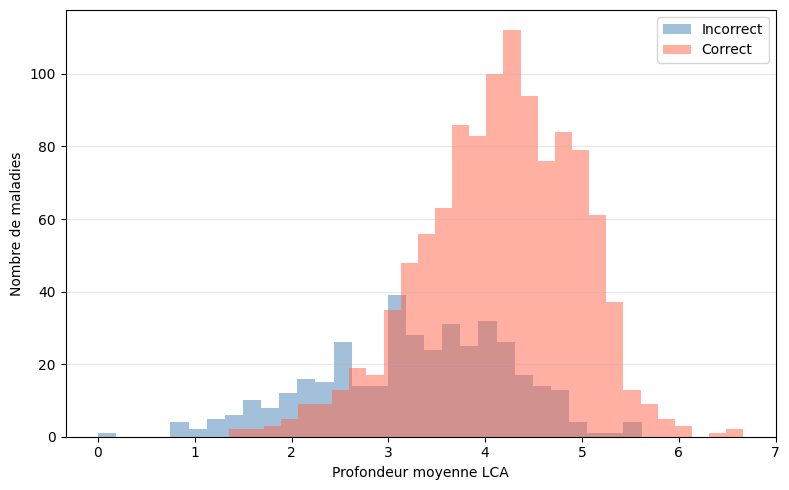

In [22]:
# Attention ! Représentation biaisée : il faut repondérer par le nombre de termes en communs (ou les omettre)
var0 = [v for k,v in lca_dist0.items()]
var1 = [v for k, v in lca_dist1.items()]

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(var0, bins=30, ax=ax, color='steelblue', alpha=0.5, edgecolor='none', label='Incorrect')
sns.histplot(var1, bins=30, ax=ax, color='tomato',    alpha=0.5, edgecolor='none', label='Correct')

ax.set_xlabel("Profondeur moyenne LCA")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [16]:
# Transport sur les paires mal transportées
wrong_omim = [work_omim0['database_id'].iloc[k[0]] for k in paires_zero_dict.keys()]
wrong_orpha = [work_orpha0['database_id'].iloc[k[1]] for k in paires_zero_dict.keys()]

omim2 = work_omim0[work_omim0['database_id'].isin(wrong_omim)].reset_index()
orpha2 = work_orpha0[work_orpha0['database_id'].isin(wrong_orpha)].reset_index()
gt_set2, valid_omim2, valid_orpha2 = f_ground_truth(omim2, orpha2, df_orpha_omim_exact)

C_jacc2 = basic_cost_matrix(omim2, orpha2, 'hamming')

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C_jacc2, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, gt_set2, C_jacc2)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C_jacc2)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C_jacc2, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, gt_set2, C_jacc2)

Check : (394, 394)
======== Sans régularisation ========
Paires évaluées : 394
Top-1 accuracy : 0.109 (43/394)
Top-3 accuracy : 0.112 (44/394)
Top-5 accuracy : 0.117 (46/394)
 Rang moyen: 174.85
======== Avec régularisation ========
2.2556634317094524
Paires évaluées : 394
Top-1 accuracy : 0.137 (54/394)
Top-3 accuracy : 0.350 (138/394)
Top-5 accuracy : 0.462 (182/394)
 Rang moyen: 40.13


In [ ]:
# Propagation des parents : améliore un tout petit peu les résultats
def propagate_terms(df, hpo_cols, ancestors, depths, k=None):
    mat = df[hpo_cols].to_numpy().copy()
    col2idx = {c: i for i, c in enumerate(hpo_cols)}
    for row in mat:
        active_terms = [hpo_cols[i] for i, v in enumerate(row) if v == 1]
        for term in active_terms:
            for anc in ancestors.get(term, []):
                if anc not in col2idx:
                    continue
                if k is None or depths[term] - depths[anc] <= k:
                    row[col2idx[anc]] = 1
    df_out = df.copy()
    df_out[hpo_cols] = mat
    return df_out

work_omim0_P = propagate_terms(work_omim0,  hpo_cols, ancestors, depths, k=2)
work_orpha0_P = propagate_terms(work_orpha0, hpo_cols, ancestors, depths, k=2)

In [33]:
C_jacc = compute_cost_matrix_pseudo_jacc(work_omim0_P, work_orpha0_P, node2id_w, model)

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C_jacc, a=None, b=None)
ranks, pairs = evaluate_transport(ot_plan, gt_set, C_jacc)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[2] * np.mean(C_jacc)
print(epsilon)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C_jacc, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, gt_set, C_jacc)

Compute norms
Norms computed !
C[0,0]  ref=321.506164  new=321.506164  diff=0.00e+00
C[3,7]  ref=708.690056  new=708.690056  diff=3.41e-13
C[9,14]  ref=471.639417  new=471.639417  diff=5.68e-14
======== Sans régularisation ========
Paires évaluées : 2237
Top-1 accuracy : 0.598 (1337/2237)
Top-3 accuracy : 0.630 (1409/2237)
Top-5 accuracy : 0.631 (1412/2237)
 Rang moyen: 596.51
======== Avec régularisation ========
47.68693208736416
Paires évaluées : 2237
Top-1 accuracy : 0.595 (1332/2237)
Top-3 accuracy : 0.721 (1613/2237)
Top-5 accuracy : 0.768 (1719/2237)
 Rang moyen: 31.17


Propager les termes actifs en ajoutant leurs parents et ancêtres dans l'arbre améliore un peu les résultats, on gagne $3-4$% de maladies correctement associées, mais ne semble pas être une solution en soi. De plus, ajouter tous les ancêtres semble être relativement inefficace, parce que l'on ajoute des noeuds de moins en moins informatifs, ce qui peut avoir pour conséquence de bruiter/noyer un peu le signal. Prendre $k=2$ ou $3$ dans le code qui précède apparaît comme le mieux.

In [9]:
# Test : visualisation des barycentres de maladies mal transportées
work_omim0_bary = work_omim0_P.copy()
work_omim0_bary = compute_disease_barycenters(work_omim0_bary, node2id_w, model, deprecated)
work_orpha0_bary = work_orpha0_P.copy()
work_orpha0_bary = compute_disease_barycenters(work_orpha0_bary, node2id_w, model, deprecated)

Barycentres: 100%|██████████| 3189/3189 [01:40<00:00, 31.75it/s]


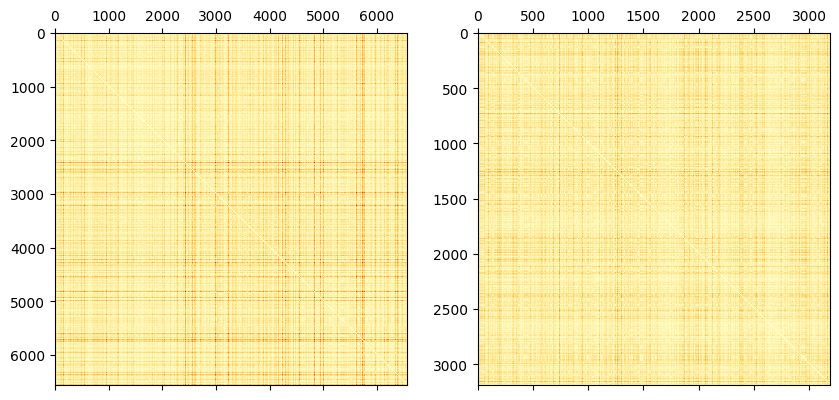

In [18]:
C_bary = compute_cost_matrix(work_omim0_bary, work_orpha0_bary)
max_C=np.max(C_bary)
C_bary = (C_bary/max_C)**2

Ss_bary = compute_cost_matrix(work_omim0_bary, work_omim0_bary)
max_Ss = np.max(Ss_bary)
Ss_bary = (Ss_bary/max_Ss)**2
Ss_bary[Ss_bary<1e-10]=0

St_bary = compute_cost_matrix(work_orpha0_bary, work_orpha0_bary)
max_St = np.max(St_bary)
St_bary = (St_bary/max_St)**2
St_bary[St_bary<1e-10]=0

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].matshow(Ss_bary, cmap='YlOrRd')
axes[1].matshow(St_bary, cmap='YlOrRd')
plt.show()

On peut peut-être tenter un Wasserstein à deux niveaux où la distance entre deux termes n'est plus leur distance dans l'*embedding* mais le plus court chemin dans le graphe entre ces termes.

In [40]:
def cost_matrix_wasserstein_lca(df_omim, df_orpha, node2id_w, ancestors, depths, deprecated):
    hpo_cols = [c for c in df_omim.columns if c.startswith('HP:')]

    print("Precompute...")
    def precompute(df):
        '''
        Renvoie pour chaque maladie (ligne) du dataframe df la liste des termes HPO actifs et 
        le vecteur de poids uniformes associés.
        '''
        X = df[hpo_cols].to_numpy(dtype=bool)
        resolved_cols = np.array(
            [deprecated.get(col, col) if deprecated.get(col, col) in node2id_w else None for col in hpo_cols], 
            dtype=object)
        valid_mask = resolved_cols != None
        X_valid = X[:, valid_mask]
        resolved_valid = resolved_cols[valid_mask]
        terms = [list(resolved_valid[row_mask]) for row_mask in X_valid]
        weights = [np.ones(len(t)) / len(t) if t else np.array([]) for t in terms]
        return terms, weights

    terms_i, weights_i = precompute(df_omim)  # Termes actifs, poids pour les maladies sources
    terms_j, weights_j = precompute(df_orpha)  # Termes actifs, poids pour les maladies destinations
    print("Finished !")

    all_terms = list({h for ts in terms_i + terms_j for h in ts})  # Tous les termes actifs

    print("Precomputing full HPO distance matrix...")
    K = len(all_terms)
    D_full = np.zeros((K, K))
    for i in tqdm(range(K), desc='Matrice de couts premier transport'):
        for j in range(i+1, K):
            lca, d_lca = find_lca(all_terms[i], all_terms[j], ancestors, depths)
            D_full[i, j] = (depths[all_terms[i]] + depths[all_terms[j]] - 2*d_lca) #/(d_lca+1)
            D_full[j, i] = (depths[all_terms[i]] + depths[all_terms[j]] - 2*d_lca) #/(d_lca+1)
    print(f"HPO distance matrix: {D_full.shape}")
    return D_full

D_hpos = cost_matrix_wasserstein_lca(work_omim0, work_orpha0, node2id_w, ancestors, depths, deprecated)

Precompute...
Finished !
Precomputing full HPO distance matrix...


Matrice de couts premier transport:  57%|█████▋    | 6032/10649 [03:26<02:37, 29.25it/s]


KeyboardInterrupt: 

## Ajout d'une régularisation Laplacienne en utilisant les PPI

On considère que deux maladies sont similaires si leurs protéines interagissent ensemble.

In [21]:
def simi_ppi(df):
    n = df.shape[0]
    protein_to_idx = defaultdict(list)
    for i, row in df.iterrows():
        proteins = row['protein'] if isinstance(row['protein'], list) else [row['protein']]
        for p in proteins:
            if pd.notna(p):
                protein_to_idx[p].append(i)

    S = np.zeros((n, n))
    for i, row in df.iterrows():
        interactions = list(row['protein2'])
        for p in interactions:
            list_j = protein_to_idx.get(p)
            if list_j is not None :
                for j in list_j:
                    S[i, j]=1
                    S[j, i]=1
    return S

df1_omim0 = df1_omim[df1_omim['disease_id'].isin(work_omim0['database_id'])].reset_index()
df1_orpha0 = df1_orpha[df1_orpha['disease_id'].isin(work_orpha0['database_id'])].reset_index()

simi_source = simi_ppi(df1_omim0)
simi_target = simi_ppi(df1_orpha0)

Text(0.5, 1.0, 'Target')

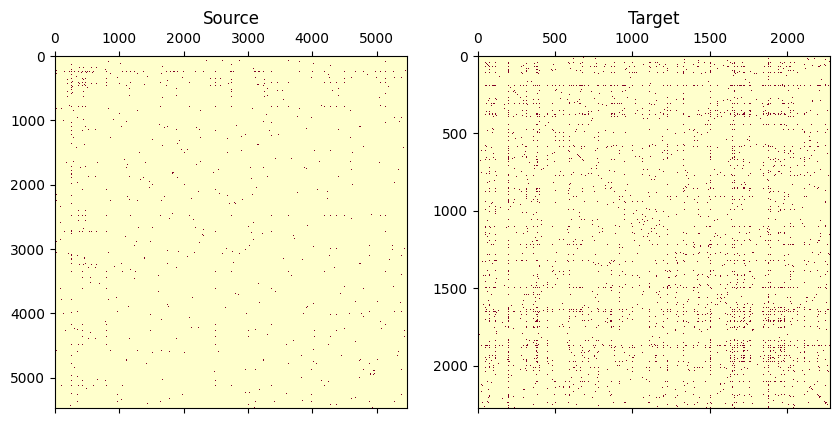

In [35]:
# Matrices de similarités : il faudrait ordonner les colonnes selon gene_gt_set ? 
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].matshow(simi_source, cmap="YlOrRd")
axes[0].set_title("Source")
axes[1].matshow(simi_target, cmap="YlOrRd")
axes[1].set_title("Target")

In [ ]:
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_array
n_comp1, labels1 = connected_components(csr_array(simi_source))
print(n_comp1)
n_comp2, labels2 = connected_components(csr_array(simi_target))
print(n_comp2)

1
1


In [15]:
def gcg0(a,
    b,
    M,
    f,
    df,
    reg1,
    reg2,
    lp_solver,
    line_search,
    G0=None,
    numItermax=200,
    stopThr=1e-9,
    stopThr2=1e-9,
    **kwargs
    #log=False
    ):
    loop = 1
    #if log:
        #log = {"loss": []}
    if G0 is None:
        G = np.outer(a, b)
    else:
        G = np.copy(G0)
    if reg2 is None:
        def cost(G):
            return np.sum(M * G) + reg1 * f(G)
    else:
        def cost(G):
            return np.sum(M * G) + reg1 * f(G) + reg2 * np.sum(G * np.log(G))
    cost_G = cost(G)
    #if log:
        #log["loss"].append(cost_G)
    df_G = None
    it = 0
    while loop:
        it += 1
        old_cost_G = cost_G
        # problem linearization
        if df_G is None:
            df_G = df(G)
        Mi = M + reg1 * df_G
        if reg2 is not None:
            Mi = Mi + reg2 * (1 + nx.log(G))

        # solve linear program
        Gc, innerlog_ = lp_solver(a, b, Mi, **kwargs)
        # line search
        deltaG = Gc - G

        res_line_search = line_search(cost, G, deltaG, Mi, cost_G, df_G, **kwargs)
        if len(res_line_search) == 3:
            # the line-search does not allow to update the gradient
            alpha, fc, cost_G = res_line_search
            df_G = None
        else:
            # the line-search allows to update the gradient directly
            # e.g. while using quadratic losses as the gromov-wasserstein loss
            alpha, fc, cost_G, df_G = res_line_search

        G = G + alpha * deltaG

        # test convergence
        if it >= numItermax:
            loop = 0

        abs_delta_cost_G = abs(cost_G - old_cost_G)
        relative_delta_cost_G = (
            abs_delta_cost_G / abs(cost_G) if cost_G != 0.0 else np.nan
        )
        if relative_delta_cost_G < stopThr or abs_delta_cost_G < stopThr2:
            loop = 0

        #if log:
            #log["loss"].append(cost_G)
    return G

In [ ]:
# Inspiré du code emd_laplace de la librairie POT
from ot import sinkhorn
from ot.optim import cg, gcg
from sklearn.neighbors import kneighbors_graph

def laplacian(x):
    r"""Compute Laplacian matrix"""
    L = np.diag(np.sum(x, axis=1)) - x
    return L

def otda(
    a, b, 
    df_source, df_target, 
    C, 
    Ss, St,
    epsilon,
    eta=1., 
    alpha=0.5, 
    reg="pos", 
    numItermax=1000,
    stopThr=1e-9,
    numInnerItermax=10_000,
    stopInnerThr=1e-9,
    log=False,
    verbose=False):

    n, m = C.shape
    if a is None:
        a = np.ones(n)/n
    if b is None:
        b = np.ones(m)/m

    xs = np.asarray(df_source, dtype=np.float64)
    xt = np.asarray(df_target, dtype=np.float64)
    print('xs', xs.shape)
    print('xt', xt.shape)
    if Ss is None or St is None :
        sim_param = 10
        Ss = kneighbors_graph(X=xs, n_neighbors=int(sim_param)).toarray()
        St = kneighbors_graph(X=xt, n_neighbors=int(sim_param)).toarray()
    sS = (Ss + Ss.T) / 2  
    sT = (St + St.T) / 2
    print('sS', sS.shape)
    print('sT', sT.shape)
    print("sS symétrique ?", np.allclose(sS, sS.T))
    print("sS valeurs négatives ?", (sS < 0).any())
    print("diag(sS) :", np.diag(sS)[:5])

    lS = laplacian(sS)
    lT = laplacian(sT)
    print('lS', lS.shape)
    print('lT', lT.shape)

    ls2 = lS + lS.T
    lt2 = lT + lT.T
    xt2 = np.dot(xt, xt.T)
    xs2 = np.dot(xs, xs.T)

    if reg == "disp":
        Cs = -eta * alpha / xs.shape[0] *(ls2 @ xs @ xt.T)
        Ct = -eta * (1 - alpha) / xt.shape[0] * (xs @ xt.T @ lt2)
        C = C + Cs + Ct

    def f(G):
        #GXt = G @ xt
        #term1 = np.einsum('ij,ij->', lS @ GXt, GXt)
        #term1 = np.trace(G.T.dot(ls2*0.5).dot(G))
        #GtXs = G.T @ xs
        #term2 = np.einsum('ij,ij->', lT @ GtXs, GtXs)
        #term2 = np.trace(G.dot(lt2*0.5).dot(G.T))
        #return alpha * term1 + (1 - alpha) * term2
        return alpha * np.trace(xt.T @ G.T @ lS @ G @ xt) + (1 - alpha) * np.trace(xs.T @ G @ lT @ G.T @ xs)

    def df(G):
        #return alpha * (ls2 @ G) + (1-alpha) * (G @ lt2)
        return alpha * (ls2 @ G @ xt2) + (1 - alpha) * (xs2 @ G @ lt2)

    assert (C >= 0).all(), "C contient des valeurs négatives !"
    G_emd = sinkhorn(a, b, C, reg=epsilon*np.mean(C), numItermax=10_000)
    G_emd = G_emd/G_emd.sum()
    print("G0 nan:", np.isnan(G_emd).any())
    G0Xt = G_emd @ xt
    term1 = np.einsum('ij,ij->', lS @ G0Xt, G0Xt)
    G0tXs = G_emd.T @ xs
    term2 = np.einsum('ij,ij->', lT @ G0tXs, G0tXs)
    f_Gemd = alpha * term1 + (1 - alpha) * term2

    print("f(G_emd):", f_Gemd) 
    print("⟨G_emd, C⟩ :", np.sum(G_emd * C))
    print("ratio :", np.sum(G_emd * C) / f_Gemd)
    eta_calibrated = np.sum(G_emd*C)/f_Gemd
    return gcg(
        a,
        b,
        C,
        reg1=eta_calibrated*eta,
        reg2=epsilon,
        f=f,
        df=df,
        G0=None,
        numItermax=100, 
        numInnerItermax=100_000, 
        stopThr=1e-09, 
        stopThr2=1e-09, 
        verbose=True
    )


'\n    def lp_solver(a, b, M, **kwargs):\n        return sinkhorn(a, b, M, reg=epsilon, \n                        numItermax=numInnerItermax,\n                        stopThr=1e-9)\n\n    G = a[:, None] * b[None, :]\n    print(\'G\', G.shape)\n    for i in tqdm(range(numItermax)):\n        M = C + eta * df(G)\n        G_new = sinkhorn(a, b, M, reg=epsilon,\n                         numItermax=numInnerItermax,\n                         stopThr=1e-9)\n        # Line search : pas optimal entre G et G_new\n        delta = G_new - G\n        G = G + 1.0 / (i + 2) * delta  # pas décroissant classique\n        err = np.max(np.abs(delta))\n        if verbose:\n            print(f"iter {i}: err={err:.2e}")\n        if err < stopThr:\n            break\n\n    return G\n'

In [22]:
work_omim00 = work_omim0[work_omim0['database_id'].isin(df1_omim0['disease_id'])].reset_index()
work_orpha00 = work_orpha0[work_orpha0['database_id'].isin(df1_orpha0['disease_id'])].reset_index()
work_cols = [c for c in work_omim00.columns if c.startswith("HP")]
gt_set00, valid_omim0, valid_orpha0 = f_ground_truth(work_omim00, work_orpha00, df_orpha_omim_exact)

In [ ]:
# weights, _, _ = compute_information_content(gene_omim, G_hpo_work)
# weights = {t:-np.log(w) for t, w in weights.items()}
print("Computing cost...")
C = basic_cost_matrix(work_omim00, work_orpha00, 'hamming')
print("Done !")
#grid = np.linspace(0.01, 5, 100)
#epsilon = grid[1]*np.mean(C)
#print(f"Epsilon = {epsilon}")
for eta in [0.01, 0.1, 1., 100, 1000]:
    for epsilon in [0.01, 0.1, 1, 10.]:
        epsilon0 = epsilon * np.mean(C)
        print(f"Eta = {eta} et Epsilon = {epsilon}")
        ot_lapl = otda(
        None, None,  # a, b
        work_omim00[work_cols], work_orpha00[work_cols], 
        C, 
        None, None,  # Ss, St
        epsilon, 
        eta, 
        alpha=0.5)
        print("transport computed")
        ranks_lapl, pairs_lapl = evaluate_transport(ot_lapl, gt_set00, C)

Computing cost...
Check : (5474, 2275)
Done !
Eta = 0.01 et Epsilon = 0.01
xs (5474, 11613)
xt (2275, 11613)
sS (5474, 5474)
sT (2275, 2275)
sS symétrique ? True
sS valeurs négatives ? False
diag(sS) : [0. 0. 0. 0. 0.]
lS (5474, 5474)
lT (2275, 2275)
G0 nan: False
f(G_emd): 0.01804051906013633
⟨G_emd, C⟩ : 37.604860799878885
ratio : 2084.4666760710547
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|-2.904971e+02|0.000000e+00|0.000000e+00
    1|-2.906549e+02|5.428216e-04|1.577738e-01
    2|-2.906549e+02|0.000000e+00|0.000000e+00
transport computed
Paires évaluées : 1583
Top-1 accuracy : 0.554 (877/1583)
Top-3 accuracy : 0.691 (1094/1583)
Top-5 accuracy : 0.752 (1190/1583)
 Rang moyen: 30.71
Eta = 0.01 et Epsilon = 0.1
xs (5474, 11613)
xt (2275, 11613)
sS (5474, 5474)
sT (2275, 2275)
sS symétrique ? True
sS valeurs négatives ? False
diag(sS) : [0. 0. 0. 0. 0.]
lS (5474, 5474)
lT (2275, 2275)
G0 nan: False
f(G_emd): 0.00159984065335012

## Essai de Fused Gromov Wasserstein

In [6]:
def simi_ppi_crossed(df1, df2):
    n = df1.shape[0]
    m = df2.shape[0]
    protein_to_idx1 = defaultdict(list)
    protein_to_idx2 = defaultdict(list)
    for i, row in df1.iterrows():
        proteins = row['protein'] if isinstance(row['protein'], list) else [row['protein']]
        for p in proteins:
            if pd.notna(p):
                protein_to_idx1[p].append(i)
    for j, row in df2.iterrows():
        proteins = row['protein'] if isinstance(row['protein'], list) else [row['protein']]
        for p in proteins:
            if pd.notna(p):
                protein_to_idx2[p].append(j)
    S = np.zeros((n, m))

    for i, row in df1.iterrows():
        interactions = list(row['protein2'])
        for p in interactions:
            list_j = protein_to_idx2.get(p)
            if list_j is not None :
                for j in list_j:
                    S[i, j]=1
    # Check
    S_transp = np.zeros((m, n))
    for j, row in df2.iterrows():
        interactions = list(row['protein2'])
        for p in interactions:
            list_i = protein_to_idx1.get(p)
            if list_i is not None:
                for i in list_i:
                    S_transp[j, i]=1
                    if S_transp[j, i]!=S[i, j]:
                        print("p", p)
                        print("i", i)
                        print(row)
    assert np.array_equal(S_transp.T, S), "Les deux matrices doivent être égales"
    return S, S_transp

simi_omim_orpha, S_transp = simi_ppi_crossed(df1_omim0, df1_orpha0)

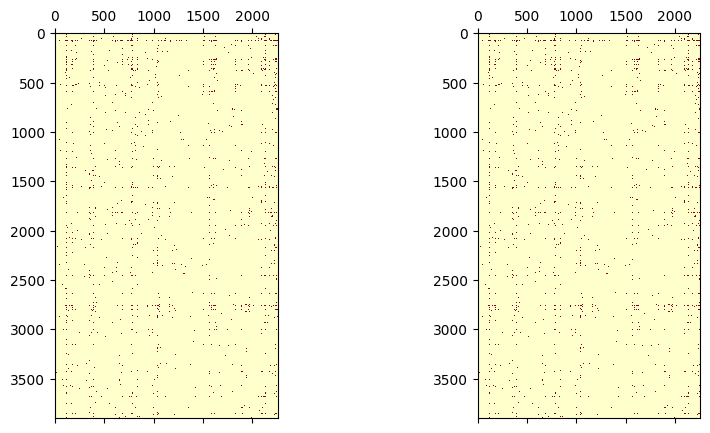

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].matshow(simi_omim_orpha, cmap="YlOrRd")
axes[1].matshow(S_transp.T, cmap="YlOrRd")

In [19]:
from ot import fused_gromov_wasserstein
from ot.gromov import entropic_fused_gromov_wasserstein

C1 = basic_cost_matrix(work_omim00, work_omim00, 'hamming')
C2 = basic_cost_matrix(work_orpha00, work_orpha00, 'hamming')

M = 1 - simi_omim_orpha
for eps in [0.1, 1., 10, 100]:
    ot_fgw = entropic_fused_gromov_wasserstein(M, C1, C2, epsilon=eps, alpha=0.9, loss_fun='kl_loss', max_iter=10e6, verbose=True)
    ranks, pairs = evaluate_transport(ot_fgw, gt_set00, None)

Check : (3902, 3902)
Check : (2258, 2258)
It.  |Err         
-------------------
    0|5.597811e-05|
   10|4.295927e-20|
Paires évaluées : 3898
Top-1 accuracy : 0.039 (151/3898)
Top-3 accuracy : 0.095 (372/3898)
Top-5 accuracy : 0.134 (521/3898)
 Rang moyen: 591.79
It.  |Err         
-------------------
    0|3.705267e-06|
   10|6.933592e-21|
Paires évaluées : 3898
Top-1 accuracy : 0.040 (156/3898)
Top-3 accuracy : 0.096 (374/3898)
Top-5 accuracy : 0.138 (538/3898)
 Rang moyen: 577.97
It.  |Err         
-------------------
    0|3.560501e-07|
   10|0.000000e+00|
Paires évaluées : 3898
Top-1 accuracy : 0.041 (158/3898)
Top-3 accuracy : 0.096 (375/3898)
Top-5 accuracy : 0.138 (538/3898)
 Rang moyen: 576.78
It.  |Err         
-------------------
    0|3.546404e-08|
   10|0.000000e+00|
Paires évaluées : 3898
Top-1 accuracy : 0.041 (158/3898)
Top-3 accuracy : 0.096 (376/3898)
Top-5 accuracy : 0.138 (538/3898)
 Rang moyen: 576.65
